# FeaturePulse — User Interaction Data Cleaning & EDA

Schemas:
`timestamp`, `user_id`, `event_name`, `feature_category`, `session_id`,
`device_type`, `browser`, `os`.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_raw = pd.read_csv("user_interactions_raw.csv")
df_raw.head()

,timestamp,user_id,event_name,feature_category,session_id,device_type,browser,os
0,2026-06-24T18:02:55Z,usr_2003,signup_started,Onboarding,sess_19144,mobile,Chrome,iOS
1,2026-06-08T05:54:55Z,usr_1895,signup_started,onboarding,sess_43118,mobile,NaN,iOS
2,2026-06-19T18:47:55Z,usr_2839,button_clicked,NaN,sess_10425,desktop,Safari,Linux
3,2026-06-19T07:35:55Z,usr_4920,payment_submitted,Checkout,sess_16698,mobile,Chrome,Android
4,2026-06-23T19:05:55Z,usr_4305,page_viewed,dashboard,sess_40108,tablet,NaN,iOS


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52490 entries, 0 to 52489
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   timestamp         52490 non-null  object
 1   user_id           52490 non-null  object
 2   event_name        52490 non-null  object
 3   feature_category  46678 non-null  object
 4   session_id        52490 non-null  object
 5   device_type       52490 non-null  object
 6   browser           41939 non-null  object
 7   os                52490 non-null  object
dtypes: object(8)
memory usage: 3.2+ MB


## Data Quality Checks

In [4]:
df_raw.isna().sum()

timestamp               0
user_id                 0
event_name              0
feature_category     5812
session_id              0
device_type             0
browser             10551
os                      0
dtype: int64

In [5]:
df_raw.duplicated().sum()

2490

In [6]:
df_raw['feature_category'].value_counts(dropna=False)

feature_category
Onboarding    5906
dashboard     5898
kpi_page      5896
Checkout      5848
checkout      5842
NaN           5812
search        5802
export        5791
onboarding    5695
Name: count, dtype: int64

## Cleaning

- Drop exact duplicate rows (dedupe retries/re-fires)
- Normalize `feature_category` casing (`Onboarding` vs `onboarding`) and fill missing values
- Parse `timestamp` to datetime

In [7]:
df = df_raw.drop_duplicates().copy()

In [8]:
df['feature_category'] = (
    df['feature_category']
    .str.strip()
    .str.lower()
    .fillna('unknown_feature')
)

In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [10]:
df['event_date'] = df['timestamp'].dt.date

## Feature Engineering

In [11]:
session_span = (
    df.groupby('session_id')['timestamp']
    .agg(lambda ts: (ts.max() - ts.min()).total_seconds())
)
df['session_duration_sec'] = df['session_id'].map(session_span)

In [12]:
df['is_bounce_session'] = df['session_duration_sec'] == 0

In [13]:
df['session_bucket'] = pd.cut(
    df['session_duration_sec'],
    bins=[-1, 0, 300, 900, 1800],
    labels=['bounce', 'short', 'medium', 'long']
)

In [14]:
df['interaction'] = 1

## Post-clean sanity check

In [15]:
df.isna().sum()

timestamp                   0
user_id                     0
event_name                  0
feature_category            0
session_id                  0
device_type                 0
browser                 10061
os                          0
event_date                  0
session_duration_sec        0
is_bounce_session           0
session_bucket          35749
interaction                 0
dtype: int64

In [16]:
df.duplicated().sum()

0

In [17]:
df.head()

,timestamp,user_id,event_name,feature_category,session_id,device_type,browser,os,event_date,session_duration_sec,is_bounce_session,session_bucket,interaction
0,2026-06-24 18:02:55+00:00,usr_2003,signup_started,onboarding,sess_19144,mobile,Chrome,iOS,2026-06-24,0.0,True,bounce,1
1,2026-06-08 05:54:55+00:00,usr_1895,signup_started,onboarding,sess_43118,mobile,NaN,iOS,2026-06-08,0.0,True,bounce,1
2,2026-06-19 18:47:55+00:00,usr_2839,button_clicked,unknown_feature,sess_10425,desktop,Safari,Linux,2026-06-19,0.0,True,bounce,1
3,2026-06-19 07:35:55+00:00,usr_4920,payment_submitted,checkout,sess_16698,mobile,Chrome,Android,2026-06-19,695700.0,False,NaN,1
4,2026-06-23 19:05:55+00:00,usr_4305,page_viewed,dashboard,sess_40108,tablet,NaN,iOS,2026-06-23,1154400.0,False,NaN,1


In [18]:
df.to_csv("user_interactions_clean.csv", index=False)

## Exploratory Analysis

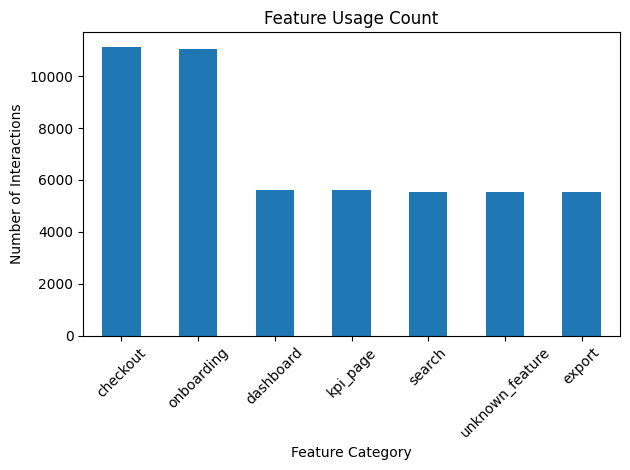

In [19]:
# What features are used the most
feature_usage = (
    df.groupby('feature_category')
    .size()
    .sort_values(ascending=False)
)

plt.figure()
feature_usage.plot(kind='bar')
plt.title("Feature Usage Count")
plt.xlabel("Feature Category")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

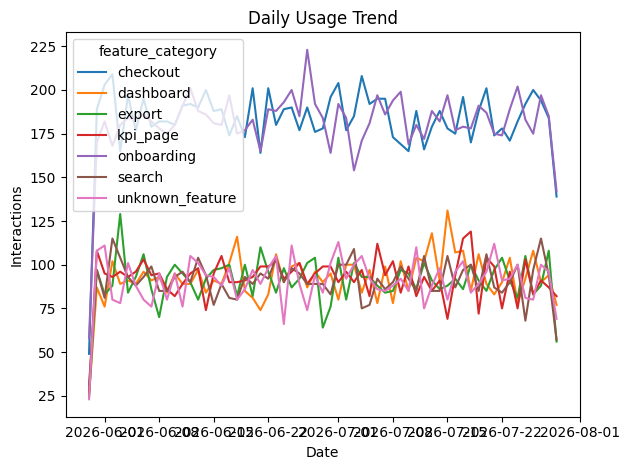

In [20]:
# How does feature usage change over time
daily_usage = (
    df.groupby(['event_date', 'feature_category'])
    .size()
    .unstack(fill_value=0)
)

plt.figure()
daily_usage.plot()
plt.title("Daily Usage Trend")
plt.xlabel("Date")
plt.ylabel("Interactions")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

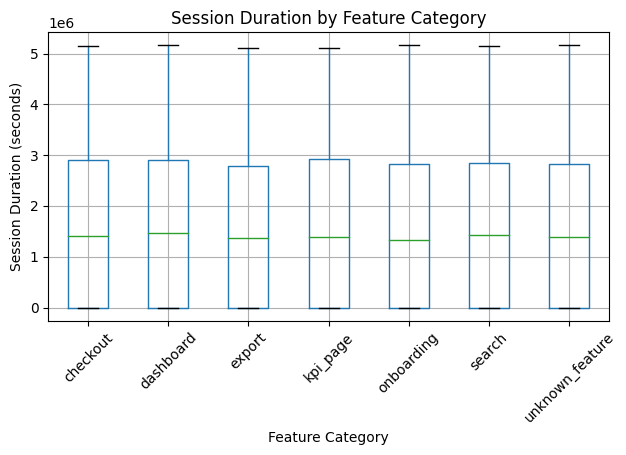

In [21]:
# Which features keep users engaged longer
plt.figure()
df.boxplot(column='session_duration_sec', by='feature_category')
plt.title("Session Duration by Feature Category")
plt.suptitle("")
plt.xlabel("Feature Category")
plt.ylabel("Session Duration (seconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

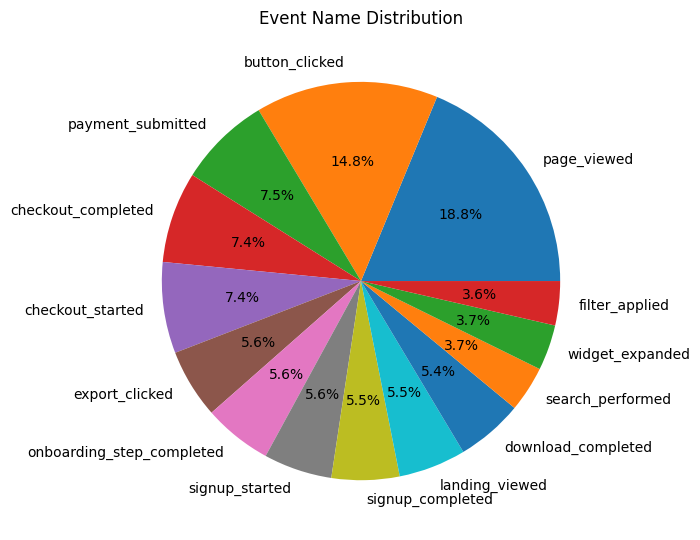

In [22]:
# What kind of events are happening
event_dist = df['event_name'].value_counts()

plt.figure(figsize=(7, 7))
event_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title("Event Name Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Platform Breakdown

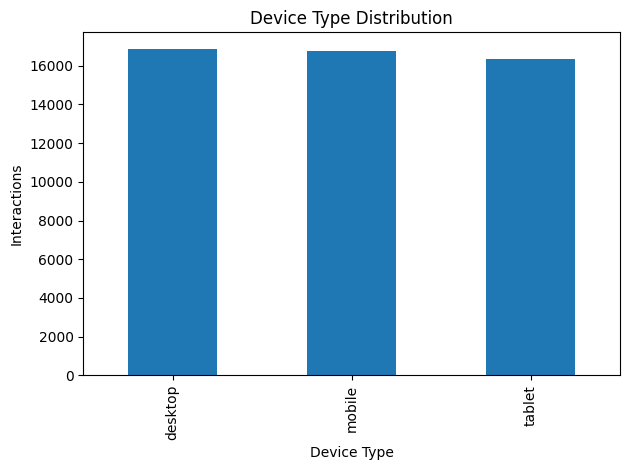

In [27]:
device_usage = df['device_type'].value_counts()

plt.figure()
device_usage.plot(kind='bar')
plt.title("Device Type Distribution")
plt.xlabel("Device Type")
plt.ylabel("Interactions")
plt.tight_layout()
plt.show()

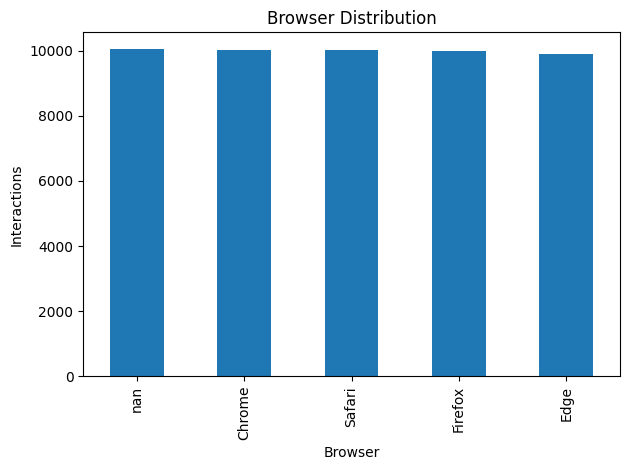

In [28]:
browser_usage = df['browser'].value_counts(dropna=False)

plt.figure()
browser_usage.plot(kind='bar')
plt.title("Browser Distribution")
plt.xlabel("Browser")
plt.ylabel("Interactions")
plt.tight_layout()
plt.show()

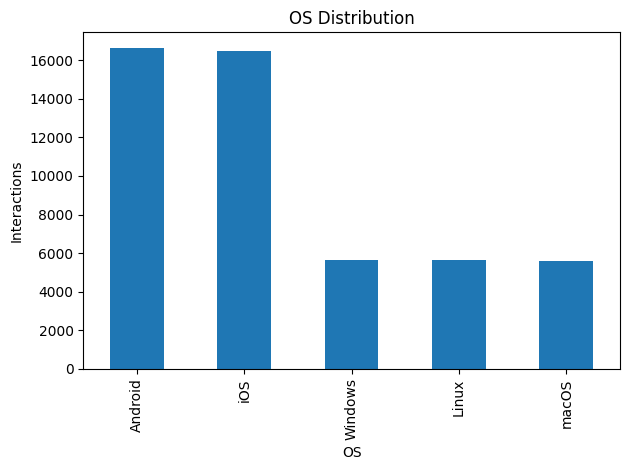

In [29]:
os_usage = df['os'].value_counts()

plt.figure()
os_usage.plot(kind='bar')
plt.title("OS Distribution")
plt.xlabel("OS")
plt.ylabel("Interactions")
plt.tight_layout()
plt.show()

In [30]:
# Bounce rate — single-event sessions, per PRD 4.3
bounce_rate = df.drop_duplicates('session_id')['is_bounce_session'].mean()
print(f"Bounce rate: {bounce_rate:.2%}")

Bounce rate: 49.92%
